# Emotion extraction from the social media Twitter emotion classifcation

## The code I provided is focused on emotion classification from tweets, which involves several key steps to process text data from social media (specifically Twitter) and classify it into different emotional categories.  main components:

   ### 1. Tokenization:
   #### The process begins with tokenization, where the text of tweets is split into smaller units called tokens (either words or characters). This is necessary because models like DistilBERT cannot process raw text directly.

  ### 2. Character and Word Tokenization:
  ####    ◦ The code discusses two types of tokenization: character tokenization, which breaks down text into individual characters, and word tokenization, which splits the text into words. Each token is then mapped to a unique integer for further processing.

  ### 3. Subword Tokenization:
  #### The code mentions subword tokenization, which combines the advantages of character and word tokenization. It uses algorithms like WordPiece, which is particularly useful in handling out-of-vocabulary words by breaking them down into known subwords.

  ###  4. Model Selection:
  #### The code utilizes a pretrained model (DistilBERT) for emotion classification. DistilBERT is a smaller, faster, and lighter version of BERT (Bidirectional Encoder Representations from Transformers), which is designed for natural language processing tasks.

 ### 5. Feature Extraction:
  #### After tokenizing the tweets, the next step involves extracting features from the text using the DistilBERT model. This involves converting the tokens into embeddings (numerical representations) that capture semantic information about the text.

### 6. Training a Classifier:
  #### The extracted features are then used to train a classifier (like logistic regression or a neural network) to predict the emotional labels associated with each tweet. The model is fine-tuned to improve its performance on the specific task of emotion classification.

  ### 7. Evaluation:
  #### The model's performance is evaluated using metrics such as accuracy and F1 score, and confusion matrices are plotted to visualize how well the model is distinguishing between different emotional categories.

### 8. Visualization:
  #### The code includes steps to visualize the distribution of emotions in the dataset and the performance of the model, helping to understand the classification results better.

  ### 9. Prediction on New Data:
  #### Finally, the trained model can be used to make predictions on new, unseen tweets, allowing for real-time emotion classification.

### Overall, the code represents a comprehensive approach to extracting and classifying emotions from social media data, leveraging modern NLP techniques and pretrained transformer models to achieve this task effectively.



### <b><span style='color:#F1A424'>Test Classification</span></b>

- Text classification is one of the most common tasks in NLP
- It can be used for a wide range of applications (eg. tagging customer feedback into categories, routing support tickets according to their language)
- Another common type of text classification problem is **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">sentiment analysis</mark>** which aims to **identify the polatity** of a given text (+/-)

### <b><span style='color:#F1A424'>Our Task</span></b>

- We need to build a system that will be able to automatically identify emotional states (eg. anger, joy) that people express about your company's product on twitter
- For this task, we'll be using a variant of **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">BERT</mark>**; **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">DistilBERT</mark>**, the main advantage of this model is that it is much smaller than **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">BERT</mark>** (ie. more efficient), but is able to achieve comparable performance

- We will be using three core libraries from the **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">Hugging Face</mark>** ecosystem: **<span style='color:#FFC300'>Datasets</span>**, **<span style='color:#FFC300'>Tokenizers</span>** & **<span style='color:#FFC300'>Transformers</span>**

In [ ]:
import panel as pn

# Load the Panel extension
pn.extension()

<ipython-input-1-f1b5a3575298>:4: UserWarning: Using Panel interactively in Colab notebooks requires the jupyter_bokeh package to be installed. Install it with:

    !pip install jupyter_bokeh

and try again.
  pn.extension()


In [ ]:
import pandas as pd
import numpy as np
import panel as pn
import warnings; warnings.filterwarnings('ignore')
from google.colab import files

uploaded = files.upload()
uploaded = files.upload()
uploaded = files.upload()


Saving validation.csv to validation.csv


Saving training.csv to training.csv


Saving test.csv to test.csv


In [ ]:

def show_panel(df):
    return pn.widgets.Tabulator(df.head(20),
                    show_index=False,
                    pagination='local',
                         page_size=10)

# Load the datasets
validation = pd.read_csv('/content/test.csv')
train = pd.read_csv('/content/training.csv')
test = pd.read_csv('/content/validation.csv')

# Display dataset information
print('Dataset information:')
print(f'Training data: {train.shape}')
print(f'Validation data: {validation.shape}')
print(f'Test data: {test.shape}')

Dataset information:
Training data: (16000, 2)
Validation data: (2000, 2)
Test data: (2000, 2)


### <b><span style='color:#F1A424'>Combine DataFrames into Dataset</span></b>
- It can be more intuitive to utilise **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">HuggingFace</mark>**'s Dataset  

In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 16.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [ ]:
from datasets import Dataset,DatasetDict,Features,Value,ClassLabel

# Don't forget the class label data
class_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
ft = Features({'text': Value('string'), 'label': ClassLabel(names=class_names)})

# Combine Multiple Datasets
emotions = DatasetDict({
    "train": Dataset.from_pandas(train,features=ft),
    "test": Dataset.from_pandas(test,features=ft),
    "validation": Dataset.from_pandas(validation,features=ft)
    })

# Convert a single DataFrame to a Dataset
# emotions = Dataset.from_pandas(train,features=ft)

emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

### <b><span style='color:#F1A424'>Selecting a Subset</span></b>
- We'll be working with the **training and validation dataset** in this problem
- Lets just show some useful fearures of the **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">Dataset</mark>** class

In [ ]:
# Training Data
train_ds = emotions["train"]
train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [ ]:
# Get First 5 Entries in Dictionary Format (Group them)
train_ds[:5]


{'text': ['i didnt feel humiliated',
  'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
  'im grabbing a minute to post i feel greedy wrong',
  'i am ever feeling nostalgic about the fireplace i will know that it is still on the property',
  'i am feeling grouchy'],
 'label': [0, 0, 3, 2, 3]}

### <b><span style='color:#F1A424'>Dataset to DataFrame Convertion</span></b>
- Whenever we need a pandas `DataFrame`, eg. for visualisations, we can utlise the `Dataset`'' method `.set_format`

In [ ]:
# Convert Dataset to DataFrame (don't forget to reset)
emotions.set_format(type="pandas")
df = emotions["train"][:]
show_panel(df)


pn.extension('tabulator')


pn.extension('tabulator')



Tabulator(page_size=10, pagination='local', show_index=False, value=              ...)

### <b><span style='color:#F1A424'>Adding Label Data</span></b>
- We made sure to not forget the `label_names` when converting from `DataFrame` to `Dataset`
- We can convert **numeric** values to **string** values by using method `int2str`

In [ ]:
# Add label data to dataframe
def label_int2str(row):
    return emotions["train"].features["label"].int2str(row)

df["label_name"] = df["label"].apply(label_int2str)
show_panel(df)

Tabulator(page_size=10, pagination='local', show_index=False, value=              ...)

# <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;overflow:hidden;background-color:#3b3745"><b><span style='color:#F1A424'>2 |</span></b> <b>CLASS DISTRIBUTION</b></div>

- Our dataset has 6 classes `joy`, `sadness`, `anger`, `fear`, `love` and `surprise`; multiclass problem

In [ ]:
import plotly.express as px
import pandas as pd


# Calculate the value counts
value_counts = df['label_name'].value_counts(ascending=True).reset_index()
value_counts.columns = ['Label Name', 'Count']

# Create a bar chart with enhanced styling
fig = px.bar(value_counts,
             x='Count',
             y='Label Name',
             template='plotly_white',
             color='Count',  # Color by count for better distinction
             color_continuous_scale=px.colors.sequential.Viridis,  # Use a sequential color scale
             title='Counts of Each Label',  # Main title for the chart
             labels={'Count': 'Count of Instances', 'Label Name': 'Label'},  # Axis labels
             text='Count'  # Display count values on the bars
            )

# Update layout for better aesthetics
fig.update_traces(texttemplate='%{text}', textposition='outside')  # Position text outside
fig.update_layout(
    title_font=dict(size=24, color='black'),  # Customize title font size and color
    xaxis_title_font=dict(size=18, color='black'),  # Customize x-axis title font
    yaxis_title_font=dict(size=18, color='black'),  # Customize y-axis title font
    legend_title_font=dict(size=14),  # Customize legend title font
    legend=dict(x=1, y=1, traceorder='normal', orientation='h'),  # Customize legend position
    margin=dict(l=40, r=40, t=60, b=40)  # Adjust margins
)

# Show the figure
fig.show()

# <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;overflow:hidden;background-color:#3b3745"><b><span style='color:#F1A424'>3 |</span></b> <b>LENGTH OF EACH TWEET</b></div>

- For applications using **DistilBERT**, the maximum context size is **512 tokens**
- Most tweets are around **10-20 words** long, which falls well within this limit

In [ ]:
import pandas as pd
import plotly.express as px

# Calculate the number of words per tweet
df["Words Per Tweet"] = df["text"].str.split().apply(len)

# Create the box plot with enhanced visuals
fig = px.box(
    df,
    y='Words Per Tweet',
    color='label_name',
    title='Distribution of Words Per Tweet by Label',
    labels={
        'Words Per Tweet': 'Number of Words',
        'label_name': 'Label Name'
    },
    template='plotly_white',
    color_discrete_sequence=px.colors.qualitative.Set2,  # Change color palette
)

# Customize layout
fig.update_layout(
    title_font=dict(size=24, color='darkblue'),
    yaxis_title_font=dict(size=16, color='dimgray'),
    xaxis_title_font=dict(size=16, color='dimgray'),
    legend_title_font=dict(size=16),
    boxmode='group'  # Side-by-side box plots
)

# Adding hover information for better understanding
fig.update_traces(
    boxmean='sd',  # Display mean and standard deviation in the hover info
    hovertemplate='Label: %{color}<br>Words Per Tweet: %{y}<br>Mean: %{mean:.2f}'
)

# Show the figure
fig.show()

# <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;overflow:hidden;background-color:#3b3745"><b><span style='color:#F1A424'>4 |</span></b> <b>TOKENISATION</b></div>

- As with other models, **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">DistilBERT</mark>** cannot receive raw python strings as input
- Instead we need to break down the strings into subgroups called **tokens** and encode them as **numerical vectors**
- Let's consider two types of **tokenisation** approaches: **<span style='color:#FFC300'>character</span>** & **<span style='color:#FFC300'>word</span>** tokenisation

### <b><span style='color:#F1A424'> 4.1 | </span>Character tokenisation </b>

The simplest tokenisation approach is **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">character tokenisation</mark>**, we can use python's inbuilt **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">list</mark>** class

In [ ]:
text = 'Tokenisation of text is a core task of NLP.'
tokenised_text = list(text)

# Character Tokenised list
print(f'Number of tokens: {len(tokenised_text)}')
print(tokenised_text)

Number of tokens: 43
['T', 'o', 'k', 'e', 'n', 'i', 's', 'a', 't', 'i', 'o', 'n', ' ', 'o', 'f', ' ', 't', 'e', 'x', 't', ' ', 'i', 's', ' ', 'a', ' ', 'c', 'o', 'r', 'e', ' ', 't', 'a', 's', 'k', ' ', 'o', 'f', ' ', 'N', 'L', 'P', '.']


- Convert each character into an integer (numericalisation)
- `token2idx` gives us a mapping from each character in the **vocabulary** to a unique integer

In [ ]:
# Mapping Vecabulary dictionary
token2idx = {ch: idx for idx, ch in enumerate(sorted(set(tokenised_text)))}

print(f'Length of vocabulary: {len(token2idx)}')
print(token2idx)

Length of vocabulary: 18
{' ': 0, '.': 1, 'L': 2, 'N': 3, 'P': 4, 'T': 5, 'a': 6, 'c': 7, 'e': 8, 'f': 9, 'i': 10, 'k': 11, 'n': 12, 'o': 13, 'r': 14, 's': 15, 't': 16, 'x': 17}


### <b><span style='color:#F1A424'>Reconstructing text</span></b>
- Once we have a vocabulary dictionary, we can reconstruct the

In [ ]:
# Let's represent text in numerical format
input_ids = [token2idx[token] for token in tokenised_text]

print(f'{len(input_ids)} characters')
print(input_ids)

43 characters
[5, 13, 11, 8, 12, 10, 15, 6, 16, 10, 13, 12, 0, 13, 9, 0, 16, 8, 17, 16, 0, 10, 15, 0, 6, 0, 7, 13, 14, 8, 0, 16, 6, 15, 11, 0, 13, 9, 0, 3, 2, 4, 1]


### <b><span style='color:#F1A424'>Convert to OHE</span></b>

- Last step is to convert `input_ids` to a 2D tensor of one-hot vectors, let's use pytorch below
- One-Hot vectors are frequently used in ML applications to encode **categorical data** (either ordinal or nominal)
- For each of the 42 input token, we now have a one-hot vector with 18 dimensions (vocab size)

In [ ]:
import torch
import torch.nn.functional as F

inputs_ids = torch.tensor(input_ids)
one_hot_encodings = F.one_hot(inputs_ids,num_classes = len(token2idx))
print(f'OHE size: {one_hot_encodings.shape}')

OHE size: torch.Size([43, 18])


### <b><span style='color:#F1A424'>Drawbacks of Character Tokenisation</span></b>

- Character level tokenisation ignores any structure in the text & treats the whole string as a stream of characters
- This helps deal with missspellings and rear words, but the main drawback is that linguistic structures need to be learned from the data
- **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">Character tokenisation</mark>** is rarely used in practice, instead **some structure of the text is preserved** if we utilise **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">Word Tokenisation</mark>**

### <b><span style='color:#F1A424'> 4.2 | </span>Word tokenisation </b>

- Instead of splitting the text into characters, we can split **it into words** & **map each word to an integer**
- The simplest form of tokenisation is if we utilise python's inbuilt **string** class `split` method
- Unlike **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">Character tokenisation</mark>**, if we have declinations, conjugations, misspellings, the size of the **vocabulary dictionary** can grow very rapidly
- Larger **vocabularies** are a problem, because it requires the model to have an excess of parameters (which is inefficient)


- It's common to select the **<span style='color:#FFC300'>most common 100,000 words</span>** in the **corpus**
- words that are not part of the vocabulary are classified as unknown and mapped to a shared **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">UNK</mark>** token
- However, can potentially lose some important information during the process of tokenisation, since the model has no information about words associated with **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">UNK</mark>**

In [ ]:
tokenised_text = text.split()
print(tokenised_text)

['Tokenisation', 'of', 'text', 'is', 'a', 'core', 'task', 'of', 'NLP.']


### <b><span style='color:#F1A424'> 4.3 | </span>Subword tokenisation </b>

- **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">Subword tokenization</mark>** is to combine the best aspects of **<span style='color:#FFC300'>character</span>** & **<span style='color:#FFC300'>word</span>** tokenisation
- The main distinguishing feature of **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">Subword tokenization</mark>** is that it is learned from a **pretraining corpus** using a mix of statistical rules and algorithms


- There are several **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">Subword tokenization</mark>** algorithms that are commonly used in NLP
    - let’s start with `WordPiece`, which is used by the `BERT` and `DistilBERT` tokenizers
    

- `AutoTokenizer` class allows us to quickly load te tokeniser associated with a pretrained model
- Or we can load the Tokeniser manually from `transformers.DistilBertTokenizer`



In [ ]:
from transformers import AutoTokenizer

text = 'Tokenisation of text is a core task of NLP.'

# Load parameters of the tokeniser
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

# Show tokeniser information
tokenizer


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

DistilBertTokenizerFast(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [ ]:
print('')
print(f'Vocab size: {tokenizer.vocab_size}')
print(f'Max length: {tokenizer.model_max_length}')
print(f'Tokeniser model input names: {tokenizer.model_input_names}')


Vocab size: 30522
Max length: 512
Tokeniser model input names: ['input_ids', 'attention_mask']


In [ ]:
print('Encoded text')
encoded_text = tokenizer(text)
print(encoded_text,'\n')

print('Tokens')
tokens = tokenizer.convert_ids_to_tokens(encoded_text.input_ids)
print(tokens,'\n')

print('Convert tokens to string')
print(tokenizer.convert_tokens_to_string(tokens),'\n')

Encoded text
{'input_ids': [101, 19204, 6648, 1997, 3793, 2003, 1037, 4563, 4708, 1997, 17953, 2361, 1012, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]} 

Tokens
['[CLS]', 'token', '##isation', 'of', 'text', 'is', 'a', 'core', 'task', 'of', 'nl', '##p', '.', '[SEP]'] 

Convert tokens to string
[CLS] tokenisation of text is a core task of nlp. [SEP] 



In [ ]:
emotions.reset_format()

### <b><span style='color:#F1A424'> 4.4 | </span>Tokenising the entire dataset </b>

- When dealing with **text of different size**, the tokeniser will **<span style='color:#FFC300'>pad</span>** sentences of insufficient length if **padding** is selected
- The **maximum length** of the tokenised data will be the **length of the longest tweet** (in example, 2nd row)
- **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">Attention mask</mark>** helps the model understand which parts of the sentence to ignore

In [ ]:
# Tokenisation function
def tokenise(batch):
    return tokenizer(batch["text"], padding=True, truncation=True)

# Show the tokenised ids
ex_tokenised = tokenise(emotions["train"][:2])

In [ ]:
# Show attention mask
ex_tokenised['attention_mask']

[[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]

In [ ]:
# apply to the entire dataset (train,test and validation dataset)
emotions_encoded = emotions.map(tokenise, batched=True, batch_size=None)
print(emotions_encoded["train"].column_names)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

['text', 'label', 'input_ids', 'attention_mask']


# <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;overflow:hidden;background-color:#3b3745"><b><span style='color:#F1A424'>5 |</span></b> <b>TRAINING A TEXT CLASSIFIER</b></div>
subsequently also updates the parameters of the pretrained model


### <b><span style='color:#F1A424'> 5.1 | </span>Transformers as feature extractors </b>

### **<span style='color:#F1A424'>Using Pretrained Models</span>**

- We will use another auto class `AutoModel`, similar to `AutoTokenizer`
- `AutoModel` has method `from_pretrained` method to load weights of a pretrained model
- `AutoModel` class converts the token encodings to embeddings & feeds them through the encoder stack to return the **hidden states**

In [ ]:
import warnings; warnings.filterwarnings('ignore')
from transformers import AutoModel
import torch

model_ckpt = "distilbert-base-uncased"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModel.from_pretrained(model_ckpt).to(device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

### **<span style='color:#F1A424'>Extracting the last hidden state (example)</span>**
Let's extract the last **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">hidden state</mark>** for a single string
- First things first, let's encode the string and convert the tokens to Pytorch tensors
- Resulting tensor has shape **[batch_size,n_tokens]**
- Having encodings as tensors, the final step is to place them on the same device as the model & pass the inputs as follows

In [ ]:
text = "this is a test"
inputs = tokenizer(text, return_tensors="pt")
print(f"Input tensor shape: {inputs['input_ids'].size()}")

Input tensor shape: torch.Size([1, 6])


- Depending on the model configuration, the model can contain several objects (**<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">Hidden states</mark>**, **losses**, **attentions**, ...)
- The current model (`distilbert-base-uncased`) returns only one attribute, which is the `last_hidden_state`

In [ ]:
inputs = {k:v.to(device) for k,v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)
print(outputs)

BaseModelOutput(last_hidden_state=tensor([[[-0.1565, -0.1862,  0.0528,  ..., -0.1188,  0.0662,  0.5470],
         [-0.3575, -0.6484, -0.0618,  ..., -0.3040,  0.3508,  0.5221],
         [-0.2772, -0.4459,  0.1818,  ..., -0.0948, -0.0076,  0.9958],
         [-0.2841, -0.3917,  0.3753,  ..., -0.2151, -0.1173,  1.0526],
         [ 0.2661, -0.5094, -0.3180,  ..., -0.4203,  0.0144, -0.2149],
         [ 0.9441,  0.0112, -0.4714,  ...,  0.1439, -0.7288, -0.1619]]]), hidden_states=None, attentions=None)


- The hidden state tensor (`last_hidden_state`) has the size: **[batch_size,n_tokens,hidden_dim]**
- ie. 768 dimensional vector is returned for each of the 6 input tokens


- For **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">classification tasks</mark>**
    - it is common practice to just use the **hidden state associated with the [CLS] token** as the input feature

In [ ]:
print(outputs.last_hidden_state.size())
print(outputs.last_hidden_state[:,0].size())

torch.Size([1, 6, 768])
torch.Size([1, 768])


### **<span style='color:#F1A424'>Extracting the last hidden state for the Dataset</span>**

- We know how to get the last hidden state for a single string, let's repeat the process for the entire dataset using `extract_hidden_states`

In [ ]:
def extract_hidden_states(batch):

    # Place model inputs on the GPU
    inputs = {k:v.to(device) for k,v in batch.items()
              if k in tokenizer.model_input_names}

    # Extract last hidden states
    with torch.no_grad():
        last_hidden_state = model(**inputs).last_hidden_state

    # Return vector for [CLS] token
    return {"hidden_state": last_hidden_state[:,0].cpu().numpy()}

In [ ]:
emotions_encoded.set_format("torch",
                            columns=["input_ids", "attention_mask", "label"])
emotions_encoded

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 16000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [ ]:
# Extract last hidden states (faster w/ GPU)
emotions_hidden = emotions_encoded.map(extract_hidden_states, batched=True)
emotions_hidden["train"].column_names

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

['text', 'label', 'input_ids', 'attention_mask', 'hidden_state']

### **<span style='color:#F1A424'>Creating the Feature Matrix</span>**

- We have **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">hidden states</mark>** assciated with each tweet, now let's train the classifier
- To do that we need the feature matrix so we can utilise as input into the machine learning model

In [ ]:
X_train = np.array(emotions_hidden["train"]["hidden_state"])
X_valid = np.array(emotions_hidden["validation"]["hidden_state"])
y_train = np.array(emotions_hidden["train"]["label"])
y_valid = np.array(emotions_hidden["validation"]["label"])
print(f'Training Dataset: {X_train.shape}')
print(f'Validation Dataset {X_valid.shape}')

Training Dataset: (16000, 768)
Validation Dataset (2000, 768)


In [ ]:
# Let's check our dataset
X_train

array([[-0.11675142,  0.09857123, -0.12962963, ...,  0.0587109 ,
         0.35432705,  0.40420732],
       [-0.03236254, -0.03231496, -0.19572626, ..., -0.1746575 ,
         0.35463768,  0.30276567],
       [ 0.03974637,  0.2022336 ,  0.14227107, ..., -0.11406809,
         0.33937767,  0.39583123],
       ...,
       [-0.00339798, -0.09585517,  0.05843512, ..., -0.04272687,
         0.24959208,  0.30761635],
       [ 0.06660283,  0.17334355,  0.12896696, ...,  0.06118621,
         0.29038212,  0.46844175],
       [ 0.01668812,  0.10127103, -0.00731717, ..., -0.0649366 ,
         0.3454055 ,  0.21993557]], dtype=float32)

### **<span style='color:#F1A424'>Visualising the Training Data</span>**

- We can visualise each class distribution the model will need to separate in **<span style='color:#FFC300'>lower dimension space</span>** (projections onto a lower-dimensional space)
- We have a lot of **categories overlapping** in lower dimensional space (doesn't mean the model won't be able to classify them in **<span style='color:#FFC300'>higher dimensional space</span>**)
- If they are separable in the projected space, they will probably be separable in **<span style='color:#FFC300'>higher dimensional space</span>**
- We'll utilise a **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">manifold learning</mark>** unsupervised model **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">TSNE</mark>** (It will take a while)

In [ ]:
import warnings; warnings.filterwarnings('ignore')
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE

# Scale the data
X_scaled = MinMaxScaler().fit_transform(X_train)

# lower dimension transformation
model = TSNE(n_components=2).fit(X_scaled)

# Create a df of 2D embeddings
df_embedding = pd.DataFrame(model.embedding_, columns=["X", "Y"])
df_embedding["label"] = y_train

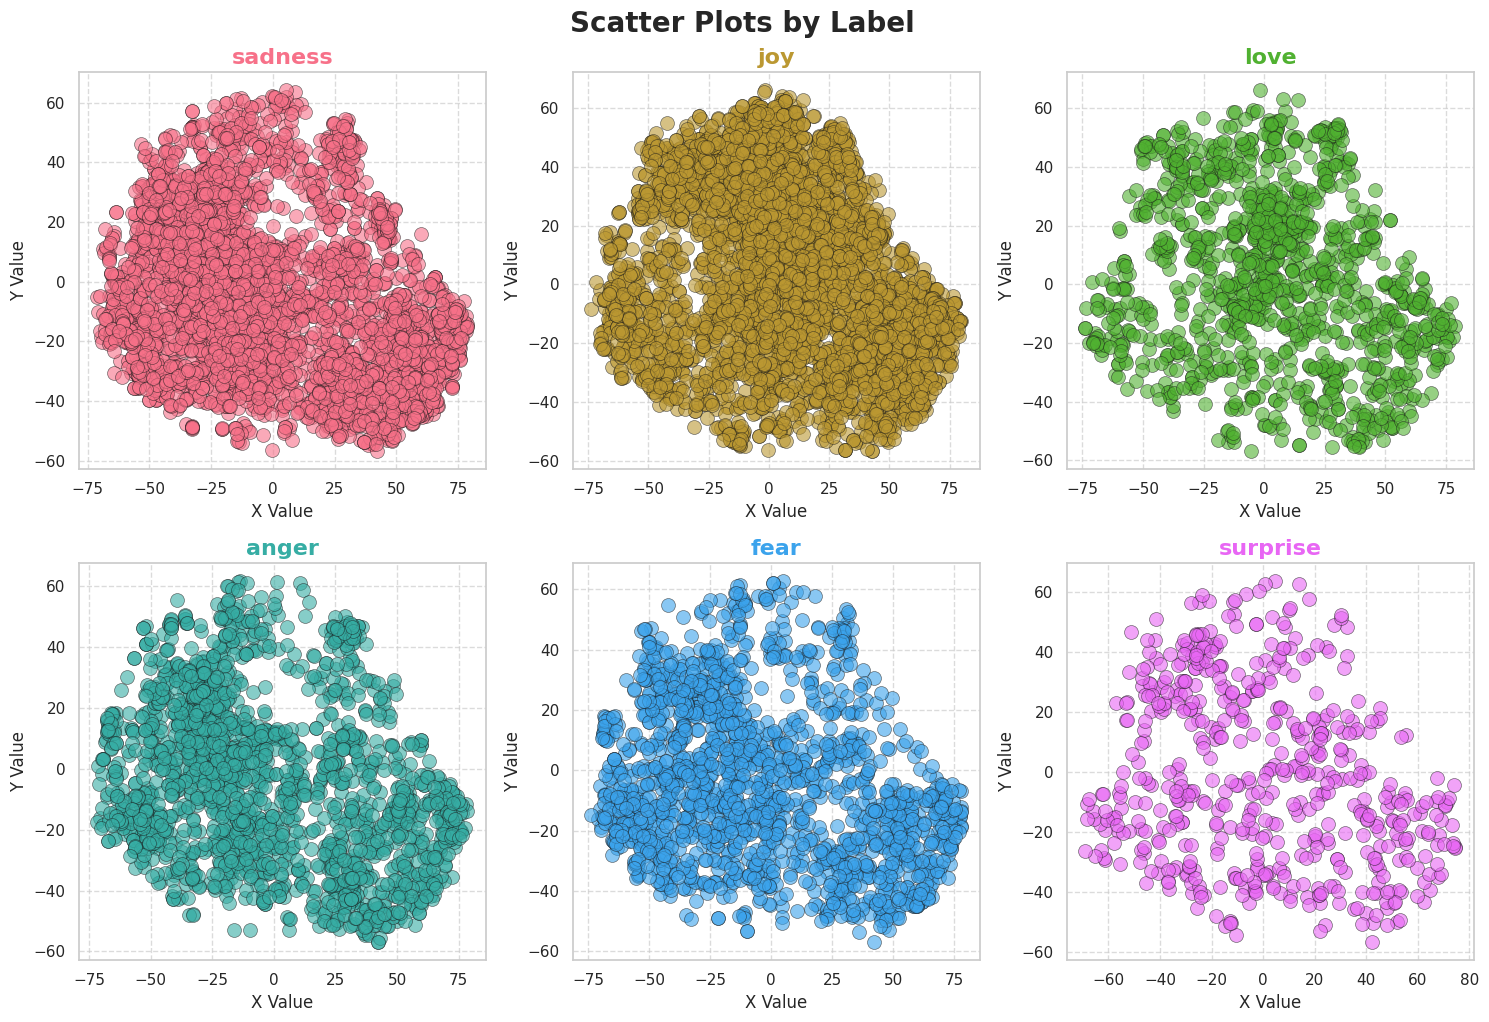

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style for seaborn
sns.set(style='whitegrid')

# Create a colormap with distinct colors for each label
num_labels = len(emotions["train"].features["label"].names)
colors = sns.color_palette("husl", num_labels)  # Use a distinct color palette

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
labels = emotions["train"].features["label"].names

# Scatter plot for each label
for i, label in enumerate(labels):
    dict_embedding_sub = dict(tuple(df_embedding.groupby('label')))
    df_embedding_sub = dict_embedding_sub[i]

    # Scatter plot with distinct colors and sizes
    scatter = axes[i].scatter(
        df_embedding_sub["X"],
        df_embedding_sub["Y"],
        lw=0.5,
        ec='k',
        alpha=0.6,
        color=colors[i],
        s=100  # Adjust marker size
    )

    # Set title with enhanced aesthetics
    axes[i].set_title(f'{label}', fontsize=16, fontweight='bold', color=colors[i])

    # Add grid for improved readability
    axes[i].grid(True, linestyle='--', alpha=0.7)

    # Set labels for the axes
    axes[i].set_xlabel('X Value', fontsize=12)
    axes[i].set_ylabel('Y Value', fontsize=12)

# Adjust tight layout for better spacing
plt.tight_layout()
plt.suptitle('Scatter Plots by Label', fontsize=20, fontweight='bold', y=1.02)  # main title
plt.show()

From this plot we can see some clear patterns:
- For **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">positive emotions</mark>** (**<span style='color:#FFC300'>joy</span>** and **<span style='color:#FFC300'>love</span>**) are well separated from the **<span style='color:#FFC300'>negative emotions</span>** and also share a similar space
- **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">Negative emotions</mark>** (**<span style='color:#FFC300'>sadness</span>**, **<span style='color:#FFC300'>anger</span>**, and **<span style='color:#FFC300'>fear</span>**) all occupy very similar regions with slightly varying distributions in **<span style='color:#FFC300'>lower dimension space</span>**
- Finally, **<span style='color:#FFC300'>surprise</span>** is somewhat scattered all over the **<span style='color:#FFC300'>lower dimension space</span>**

### **<span style='color:#F1A424'>Training a Baseline Model</span>**

- Let's use these **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">hidden states</mark>** to train a **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">logistic regression</mark>** model
- We're dealing with an unbalanced multiclass dataset, so our model may seem just better than random, but its actually better, let's compare to a `DummyClassifier`
- `DummyClassifier` can be used to build a classifier with simple heuristics (choosing the majority class/always drawing a random class),
- Let's choose most frequent (`strategy="most_frequent"`) so we have a reference model for comparison

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
print(f'accuracy: {dummy_clf.score(X_valid, y_valid)}')

accuracy: 0.3475


In [ ]:
from sklearn.linear_model import LogisticRegression as LR

# We increase `max_iter` to guarantee convergence
lr_clf = LR(max_iter = 2000)
lr_clf.fit(X_train, y_train)
y_preds = lr_clf.predict(X_valid)
print(f'accuracy: {lr_clf.score(X_valid, y_valid)}')

accuracy: 0.627


### <b><span style='color:#F1A424'>Confusion Matrix</span></b>

- Our **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">logistic regression</mark>** model with `DistilBERT` **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">embeddings</mark>** is signifcantly better than the baseline `DummyClassifier`
- Let check the **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">confusion matrix</mark>** of the **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">logistic regression</mark>** model

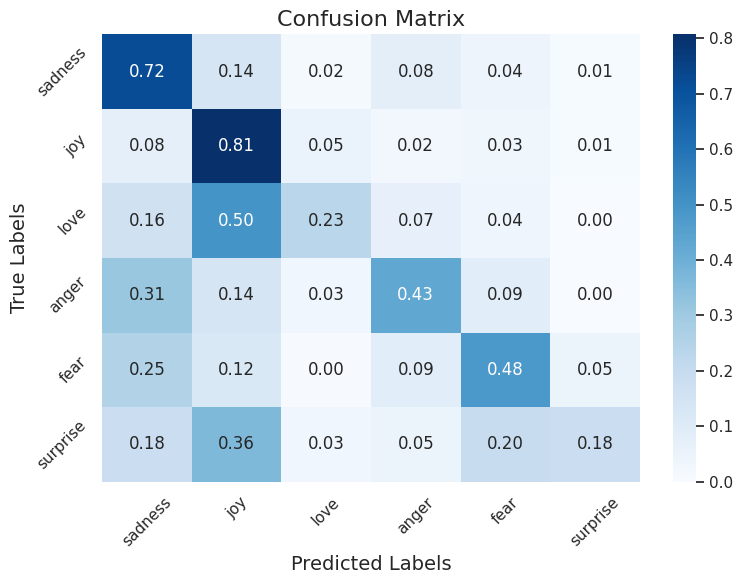

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import seaborn as sns

def plot_confusion_matrix(y_model, y_true, labels):
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_model, normalize='true')

    # Create a heatmap using seaborn for better aesthetics
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap='Blues', xticklabels=labels, yticklabels=labels, cbar=True)

    # Add titles and labels
    plt.title("Confusion Matrix", fontsize=16)
    plt.xlabel("Predicted Labels", fontsize=14)
    plt.ylabel("True Labels", fontsize=14)
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)

    # Adjust layout
    plt.tight_layout()

    # Show the plot
    plt.show()

# Example usage
plot_confusion_matrix(y_preds, y_valid, labels)


### <b><span style='color:#F1A424'> 5.2 | </span>Fine-tuning transformers </b>

- With the fine-tune approach, we do not use the **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">hidden states</mark>** as fixed features, instead, we train them from a given model state
- This requires the classification head to be differentiable (neural network for classification)

### <b><span style='color:#F1A424'>Loading a Pretrained Model</span></b>

- We'll load the same **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">DistilBERT</mark>** model using `model_ckpt` **"distilbert-base-uncased"**
- This time however we will be loading `AutoModelForSequenceClassification` (we used `AutoModel` when we extracted embedding features)
- `AutoModelForSequenceClassification` model has a **<span style='color:#FFC300'>classification head</span>** on top of the pretrained model outputs
- We only need to specify the **<span style='color:#FFC300'>number of labels</span>** the model has to predict `num_labels`

In [ ]:
import torch
from transformers import AutoModelForSequenceClassification

num_labels = 6

model_ckpt = "distilbert-base-uncased"

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = (AutoModelForSequenceClassification
         .from_pretrained(model_ckpt,
                          num_labels=num_labels)
         .to(device))

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### <b><span style='color:#F1A424'>Defining the Performance Metrics</span></b>
- We'll monitor the `F1 score`  & `accuracy`, the function is required to be passed in the `Trainer` class



In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

### <b><span style='color:#F1A424'>Training parameters</span></b>
- Next we need to define the model **training parameters**, which can be done using `TrainingArguments`
- Let's train the **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">DistilBERT</mark>** model for **3 iterations** with a **learning rate of 2e-5** and a **batch size of 64**

### <b><span style='color:#F1A424'>Train Model</span></b>
- With the training arguments set, we need to define the `Trainer` and start training with the `train()` method

In [ ]:
import panel as pn
import pandas as pd
import numpy as np
import panel as pn
import warnings; warnings.filterwarnings('ignore')
from google.colab import files

# Load the Panel extension
pn.extension()

# Upload your CSV files
uploaded = files.upload()  # Upload training.csv
uploaded = files.upload()  # Upload test.csv
uploaded = files.upload()  # Upload validation.csv

# Load the datasets
validation = pd.read_csv('test.csv') # Assuming you uploaded test.csv as test.csv
train = pd.read_csv('training.csv') # Assuming you uploaded training.csv as training.csv
test = pd.read_csv('validation.csv') # Assuming you uploaded validation.csv as validation.csv

from datasets import Dataset,DatasetDict,Features,Value,ClassLabel

# Assuming 'train', 'test', and 'validation' DataFrames are still available
# If not, you'll need to reload them.

# Don't forget the class label data
class_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
ft = Features({'text': Value('string'), 'label': ClassLabel(names=class_names)})

# Combine Multiple Datasets
emotions = DatasetDict({
    "train": Dataset.from_pandas(train,features=ft),
    "test": Dataset.from_pandas(test,features=ft),
    "validation": Dataset.from_pandas(validation,features=ft)
    })

emotions

Saving validation.csv to validation (1).csv


Saving training.csv to training (1).csv


Saving test.csv to test (1).csv


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [ ]:
from transformers import AutoTokenizer

# Load the tokenizer
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

# Tokenization function
def tokenise(batch):
    return tokenizer(batch["text"], padding=True, truncation=True)

# Apply tokenization to the emotions dataset
emotions_encoded = emotions.map(tokenise, batched=True, batch_size=None)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
from transformers import TrainingArguments, Trainer

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    evaluation_strategy="epoch"
)

# Define Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=emotions_encoded["train"],
    eval_dataset=emotions_encoded["validation"]
)

# Now you can predict
pred_output = trainer.predict(emotions_encoded["validation"])
pred_output

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


PredictionOutput(predictions=array([[-0.07656379, -0.01907511, -0.07486692, -0.14668304, -0.0783814 ,
        -0.01167009],
       [-0.12582543,  0.01505134, -0.10551003, -0.12373084, -0.0811002 ,
        -0.02085137],
       [-0.11263968,  0.00533473, -0.06057653, -0.1251587 , -0.04741603,
        -0.06856437],
       ...,
       [-0.07917647, -0.03346027,  0.02934796, -0.12934592, -0.12572685,
         0.00181935],
       [-0.09004909, -0.00646191, -0.05972435, -0.12044501, -0.07874367,
        -0.0183716 ],
       [-0.09627814, -0.00618934, -0.0711277 , -0.15776765, -0.08077221,
         0.01684034]], dtype=float32), label_ids=array([0, 0, 0, ..., 1, 1, 4]), metrics={'test_loss': 1.7924022674560547, 'test_model_preparation_time': 0.0033, 'test_accuracy': 0.18, 'test_f1': 0.14577711953449052, 'test_runtime': 218.1709, 'test_samples_per_second': 9.167, 'test_steps_per_second': 0.147})

In [ ]:
print(f'Output Predition: {pred_output.predictions.shape}')
print(pred_output.predictions)

Output Predition: (2000, 6)
[[-0.07656379 -0.01907511 -0.07486692 -0.14668304 -0.0783814  -0.01167009]
 [-0.12582543  0.01505134 -0.10551003 -0.12373084 -0.0811002  -0.02085137]
 [-0.11263968  0.00533473 -0.06057653 -0.1251587  -0.04741603 -0.06856437]
 ...
 [-0.07917647 -0.03346027  0.02934796 -0.12934592 -0.12572685  0.00181935]
 [-0.09004909 -0.00646191 -0.05972435 -0.12044501 -0.07874367 -0.0183716 ]
 [-0.09627814 -0.00618934 -0.0711277  -0.15776765 -0.08077221  0.01684034]]


In [ ]:
# Decode the predictions greedily using argmax (highest value of all classes)
y_preds = np.argmax(pred_output.predictions,axis=1)
print(f'Output Prediction:{y_preds.shape}')
print(f'Predictions: {y_preds}')

Output Prediction:(2000,)
Predictions: [5 1 1 ... 2 1 5]


In [ ]:
# Show metrics of last iteration
pred_output.metrics

{'test_loss': 1.7924022674560547,
 'test_model_preparation_time': 0.0033,
 'test_accuracy': 0.18,
 'test_f1': 0.14577711953449052,
 'test_runtime': 218.1709,
 'test_samples_per_second': 9.167,
 'test_steps_per_second': 0.147}

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import seaborn as sns

def plot_confusion_matrix(y_model, y_true, labels):
    """Plots the confusion matrix.

    Args:
        y_model: Predicted labels.
        y_true: True labels.
        labels: List of label names.
    """
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_model, normalize='true')

    # Create a heatmap using seaborn for better aesthetics
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap='Blues', xticklabels=labels, yticklabels=labels, cbar=True)

    # Add titles and labels
    plt.title("Confusion Matrix", fontsize=16)
    plt.xlabel("Predicted Labels", fontsize=14)
    plt.ylabel("True Labels", fontsize=14)
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)

    # Adjust layout
    plt.tight_layout()

    # Show the plot
    plt.show()

From the **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">confusion matrix</mark>** we can say that:
- The **fine-tune** approach (using **<mark style="background-color:#FFC300;color:white;border-radius:5px;opacity:0.7">DistilBERT</mark>**)  performs much better than simple extracting

# <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;overflow:hidden;background-color:#3b3745"><b><span style='color:#F1A424'>6 |</span></b> <b>MODEL ERROR ANALYSIS</b></div>


In [ ]:
from torch.nn.functional import cross_entropy

def forward_pass_with_label(batch):

    # Place all input tensors on the same device as the model
    inputs = {k:v.to(device) for k,v in batch.items()
              if k in tokenizer.model_input_names}

    with torch.no_grad():
        output = model(**inputs)
        pred_label = torch.argmax(output.logits, axis=-1)
        loss = cross_entropy(output.logits, batch["label"].to(device),
                             reduction="none")

    # Place outputs on CPU for compatibility with other dataset columns
    return {"loss": loss.cpu().numpy(),
            "predicted_label": pred_label.cpu().numpy()}

# Convert our dataset back to PyTorch tensors
emotions_encoded.set_format("torch",
                            columns=["input_ids", "attention_mask", "label"])
# Compute loss values
emotions_encoded["validation"] = emotions_encoded["validation"].map(forward_pass_with_label,
                                                                    batched=True,
                                                                    batch_size=16)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

### <b><span style='color:#F1A424'>Convert to DataFrame</span></b>

- Create a DataFrame with the text, losses, predicted/true labels

In [ ]:
def label_int2str(row):
    return emotions["train"].features["label"].int2str(row)

emotions_encoded.set_format("pandas")
cols = ["text", "label", "predicted_label", "loss"]
df_test = emotions_encoded["validation"][:][cols]
df_test["label"] = df_test["label"].apply(label_int2str)
df_test["predicted_label"] = (df_test["predicted_label"].apply(label_int2str))

- Now we can sort `emotions` encoded by the losses in either assending/descending order


In [ ]:
import panel as pn

# Load the Panel extension
pn.extension()

def show_panel(df):
    return pn.widgets.Tabulator(df.head(20),
                    show_index=False,
                    pagination='local',
                         page_size=10)

# ... (rest of your code) ...

show_panel(df_test.sort_values("loss", ascending=False)) # Cell ipython-input-23-02d82ee6f766


pn.extension('tabulator')


pn.extension('tabulator')



Tabulator(page_size=10, pagination='local', show_index=False, value=              ...)

In [ ]:
show_panel(df_test.sort_values("loss", ascending=True))

Tabulator(page_size=10, pagination='local', show_index=False, value=              ...)

# <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;overflow:hidden;background-color:#3b3745"><b><span style='color:#F1A424'>7 |</span></b> <b>USING OUR MODEL</b></div>

In [ ]:
# Save the model
trainer.save_model()

- My modelcan be classified to **label 1** (**joy**)

In [ ]:
from transformers import pipeline

# Load the pipeline with the correct model path and tokenizer
classifier = pipeline("text-classification", model="./results", tokenizer=model_ckpt)

# New unseen by model data
new_data = 'I have watched a movie which was quite awesome'

# Make predictions
preds = classifier(new_data, return_all_scores=True)
print(preds)

Device set to use cpu


[[{'label': 'LABEL_0', 'score': 0.16216273605823517}, {'label': 'LABEL_1', 'score': 0.17754113674163818}, {'label': 'LABEL_2', 'score': 0.17032428085803986}, {'label': 'LABEL_3', 'score': 0.15179966390132904}, {'label': 'LABEL_4', 'score': 0.16391371190547943}, {'label': 'LABEL_5', 'score': 0.17425844073295593}]]


In [ ]:
preds = classifier(new_data, return_all_scores=True)
preds

[[{'label': 'LABEL_0', 'score': 0.16216273605823517},
  {'label': 'LABEL_1', 'score': 0.17754113674163818},
  {'label': 'LABEL_2', 'score': 0.17032428085803986},
  {'label': 'LABEL_3', 'score': 0.15179966390132904},
  {'label': 'LABEL_4', 'score': 0.16391371190547943},
  {'label': 'LABEL_5', 'score': 0.17425844073295593}]]

In [ ]:
preds[0]

[{'label': 'LABEL_0', 'score': 0.16216273605823517},
 {'label': 'LABEL_1', 'score': 0.17754113674163818},
 {'label': 'LABEL_2', 'score': 0.17032428085803986},
 {'label': 'LABEL_3', 'score': 0.15179966390132904},
 {'label': 'LABEL_4', 'score': 0.16391371190547943},
 {'label': 'LABEL_5', 'score': 0.17425844073295593}]

In [ ]:
import plotly.express as px # Import the plotly.express module
import pandas as pd

# Assuming class_names is available from earlier in the code, else define here
# class_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
# or
# labels = emotions["train"].features["label"].names

df_preds = pd.DataFrame(preds[0]) # preds is a nested list: [[...]]
px.bar(x=class_names, y=100*df_preds['score'], template='plotly_white')